In [1]:
# Enhanced Installation with latest versions
!pip install transformers accelerate -q
!pip install optuna scikit-learn torchmetrics -q

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler, RobustScaler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

# Enhanced device setup with mixed precision support
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    # Enable cudnn benchmarking for faster training
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

🚀 Using device: cuda
GPU: Tesla T4
Memory: 15.64 GB


In [2]:
# Detect environment
IS_KAGGLE = os.path.exists('/kaggle/input')
DATA_PATH = "/kaggle/input/datasets/jasindavid/shifteddataset/label_shifted_fin_causality_dataset.csv" if IS_KAGGLE else r"D:\NLP_ResearchPaper_work\final_financial_causality_dataset.csv"

print(f"📍 Running on {'Kaggle' if IS_KAGGLE else 'Local'}")

# Load with enhanced parsing
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

# Enhanced temporal split (80/20 with buffer to prevent data leakage)
split_date = df["date"].quantile(0.8)
train_df = df[df["date"] <= split_date].copy()
test_df = df[df["date"] > split_date].copy()

# Shuffle training data to prevent temporal bias
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print(f"Date range - Train: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"Date range - Test: {test_df['date'].min()} to {test_df['date'].max()}")

# Check class distribution
print("\nClass Distribution:")
print(train_df["causal_label"].value_counts(normalize=True))

📍 Running on Kaggle
Train: 29442 | Test: 7230
Date range - Train: 2000-11-27 00:00:00 to 2018-04-26 00:00:00
Date range - Test: 2018-04-27 00:00:00 to 2025-04-30 00:00:00

Class Distribution:
causal_label
1    0.78551
0    0.21449
Name: proportion, dtype: float64


In [3]:
# Calculate class weights using effective number sampling (better for imbalanced data)
train_counts = train_df["causal_label"].value_counts().sort_index()
total_samples = len(train_df)

# Effective number weighting (reduces impact of majority class more aggressively)
beta = 0.9999
effective_num = 1.0 - np.power(beta, train_counts.values)
class_weights = (1.0 - beta) / effective_num
class_weights = class_weights / class_weights.sum() * len(train_counts)

print("\n🎯 Effective Number Class Weights:")
for label, weight in zip(train_counts.index, class_weights):
    print(f"Class {label}: {weight:.4f} (n={train_counts[label]})")

weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Create weighted sampler for balanced batches
sample_weights = train_df["causal_label"].map(lambda x: class_weights[x]).values
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_df), replacement=True)


🎯 Effective Number Class Weights:
Class 0: 1.3161 (n=6315)
Class 1: 0.6839 (n=23127)


In [4]:
MODEL_NAME = "ProsusAI/finbert"

# Enhanced tokenizer with financial domain specifics
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load base model with gradient checkpointing for memory efficiency
base_model = AutoModel.from_pretrained(MODEL_NAME)
base_model.gradient_checkpointing_enable()  # Saves memory, allows larger batch sizes

print(f"✅ Loaded {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Max position embeddings: {base_model.config.max_position_embeddings}")

# Test tokenization on sample
sample_text = train_df["clean_text"].iloc[0]
tokens = tokenizer(sample_text, truncation=True, max_length=256)
print(f"\nSample tokenization length: {len(tokens['input_ids'])}")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded ProsusAI/finbert
Vocab size: 30522
Max position embeddings: 512

Sample tokenization length: 256


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [5]:
class AdvancedTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256, augment=False):
        self.texts = texts.tolist() if hasattr(texts, 'tolist') else texts
        self.labels = labels.tolist() if hasattr(labels, 'tolist') else labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.augment = augment
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        
        # Simple text augmentation for minority class (random word deletion simulation via truncation)
        if self.augment and self.labels[idx] == 1 and np.random.random() > 0.5:
            words = text.split()
            if len(words) > 10:
                # Randomly truncate to simulate augmentation
                keep_ratio = np.random.uniform(0.8, 1.0)
                text = ' '.join(words[:int(len(words) * keep_ratio)])
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

class AdvancedMultimodalDataset(Dataset):
    def __init__(self, texts, numerical, labels, tokenizer, max_len=256, augment=False):
        self.texts = texts.tolist() if hasattr(texts, 'tolist') else texts
        self.numerical = numerical
        self.labels = labels.tolist() if hasattr(labels, 'tolist') else labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.augment = augment
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        
        # Augmentation for minority class
        if self.augment and self.labels[idx] == 1 and np.random.random() > 0.5:
            words = text.split()
            if len(words) > 10:
                keep_ratio = np.random.uniform(0.8, 1.0)
                text = ' '.join(words[:int(len(words) * keep_ratio)])
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "numerical": torch.tensor(self.numerical[idx], dtype=torch.float),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [6]:
class AttentionPooling(nn.Module):
    """Learned attention pooling for better sequence representation"""
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )
    
    def forward(self, hidden_states, attention_mask):
        # hidden_states: [batch, seq_len, hidden]
        scores = self.attention(hidden_states).squeeze(-1)  # [batch, seq_len]
        scores = scores.masked_fill(~attention_mask.bool(), float('-inf'))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # [batch, seq_len, 1]
        pooled = (hidden_states * weights).sum(dim=1)  # [batch, hidden]
        return pooled

class EnhancedFinBERTClassifier(nn.Module):
    def __init__(self, base_model, dropout_rate=0.3):
        super().__init__()
        self.bert = base_model
        self.hidden_size = base_model.config.hidden_size
        
        # Multi-head attention pooling instead of just CLS token
        self.attention_pool = AttentionPooling(self.hidden_size)
        
        # Layer normalization for stability
        self.layer_norm = nn.LayerNorm(self.hidden_size)
        
        # Deeper classifier with residual connections
        self.classifier = nn.Sequential(
            nn.Linear(self.hidden_size, self.hidden_size // 2),
            nn.LayerNorm(self.hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(self.hidden_size // 2, self.hidden_size // 4),
            nn.LayerNorm(self.hidden_size // 4),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(self.hidden_size // 4, 2)
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for module in self.classifier:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Use attention pooling over all tokens
        pooled = self.attention_pool(outputs.last_hidden_state, attention_mask)
        pooled = self.layer_norm(pooled)
        
        return self.classifier(pooled)

class EnhancedMultimodalFinBERT(nn.Module):
    def __init__(self, base_model, num_numerical=3, dropout_rate=0.3):
        super().__init__()
        self.bert = base_model
        self.hidden_size = base_model.config.hidden_size
        
        # Attention pooling
        self.attention_pool = AttentionPooling(self.hidden_size)
        self.layer_norm = nn.LayerNorm(self.hidden_size)
        
        # Enhanced numerical processing with deeper layers
        self.num_processor = nn.Sequential(
            nn.Linear(num_numerical, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.GELU()
        )
        
        # Fusion layer with gating mechanism
        self.fusion_gate = nn.Sequential(
            nn.Linear(self.hidden_size + 32, self.hidden_size + 32),
            nn.Sigmoid()
        )
        
        # Classifier
        combined_size = self.hidden_size + 32
        self.classifier = nn.Sequential(
            nn.Linear(combined_size, combined_size // 2),
            nn.LayerNorm(combined_size // 2),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(combined_size // 2, combined_size // 4),
            nn.LayerNorm(combined_size // 4),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(combined_size // 4, 2)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for module in [self.num_processor, self.classifier]:
            for layer in module:
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    nn.init.zeros_(layer.bias)
    
    def forward(self, input_ids, attention_mask, numerical):
        # Text branch
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_features = self.attention_pool(outputs.last_hidden_state, attention_mask)
        text_features = self.layer_norm(text_features)
        
        # Numerical branch
        num_features = self.num_processor(numerical)
        
        # Fusion with gating
        combined = torch.cat((text_features, num_features), dim=1)
        gate = self.fusion_gate(combined)
        combined = combined * gate  # Gated fusion
        
        return self.classifier(combined)

In [7]:
# Text-only datasets with augmentation for training
train_text_ds = AdvancedTextDataset(
    train_df["clean_text"], 
    train_df["causal_label"], 
    tokenizer, 
    max_len=256,
    augment=True  # Enable augmentation for minority class
)
test_text_ds = AdvancedTextDataset(
    test_df["clean_text"], 
    test_df["causal_label"], 
    tokenizer, 
    max_len=256,
    augment=False
)

# Use weighted sampler for balanced training
train_text_loader = DataLoader(
    train_text_ds, 
    batch_size=32,  # Increased batch size due to gradient checkpointing
    sampler=sampler,  # Use weighted sampler instead of shuffle
    num_workers=2,
    pin_memory=True
)
test_text_loader = DataLoader(
    test_text_ds, 
    batch_size=64, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Enhanced numerical scaling using RobustScaler (better for financial outliers)
scaler = RobustScaler()
num_train = scaler.fit_transform(train_df[["return_t1", "return_t5", "volatility_5"]])
num_test = scaler.transform(test_df[["return_t1", "return_t5", "volatility_5"]])

# Multimodal datasets
train_mm_ds = AdvancedMultimodalDataset(
    train_df["clean_text"], 
    num_train, 
    train_df["causal_label"], 
    tokenizer,
    max_len=256,
    augment=True
)
test_mm_ds = AdvancedMultimodalDataset(
    test_df["clean_text"], 
    num_test, 
    test_df["causal_label"], 
    tokenizer,
    max_len=256,
    augment=False
)

train_mm_loader = DataLoader(
    train_mm_ds, 
    batch_size=32, 
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)
test_mm_loader = DataLoader(
    test_mm_ds, 
    batch_size=64, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ DataLoaders ready")
print(f"Text batches: {len(train_text_loader)} | MM batches: {len(train_mm_loader)}")

✅ DataLoaders ready
Text batches: 921 | MM batches: 921


In [8]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif self._is_improvement(score):
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop
    
    def _is_improvement(self, score):
        if self.mode == 'max':
            return score > self.best_score + self.min_delta
        return score < self.best_score - self.min_delta

def train_model_enhanced(model, loader, val_loader, epochs=10, class_weights=None, model_name="model"):
    model.to(device)
    
    # Discriminative learning rates
    no_decay = ['bias', 'LayerNorm.weight']
    bert_params = list(model.bert.named_parameters())
    classifier_params = []
    
    if hasattr(model, 'classifier'):
        classifier_params += list(model.classifier.parameters())
    if hasattr(model, 'num_processor'):
        classifier_params += list(model.num_processor.parameters())
    if hasattr(model, 'attention_pool'):
        classifier_params += list(model.attention_pool.parameters())
    if hasattr(model, 'fusion_gate'):
        classifier_params += list(model.fusion_gate.parameters())
    
    optimizer_grouped_parameters = [
        {
            'params': [p for n, p in bert_params if not any(nd in n for nd in no_decay)],
            'weight_decay': 0.01,
            'lr': 1e-5
        },
        {
            'params': [p for n, p in bert_params if any(nd in n for nd in no_decay)],
            'weight_decay': 0.0,
            'lr': 1e-5
        },
        {
            'params': classifier_params,
            'weight_decay': 0.01,
            'lr': 5e-5
        }
    ]
    
    optimizer = AdamW(optimizer_grouped_parameters)
    
    # Scheduler
    num_training_steps = len(loader) * epochs
    num_warmup_steps = int(0.1 * num_training_steps)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )
    
    # Loss with label smoothing
    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # Mixed precision
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    
    early_stopping = EarlyStopping(patience=3, mode='max')
    best_f1 = 0.0
    best_model_state = None
    
    history = {'train_loss': [], 'val_f1': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for batch in progress_bar:
            optimizer.zero_grad()
            
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            
            # Mixed precision
            if scaler:
                with torch.cuda.amp.autocast():
                    if "numerical" in batch:
                        numerical = batch["numerical"].to(device)
                        outputs = model(input_ids, attention_mask, numerical)
                    else:
                        outputs = model(input_ids, attention_mask)
                    loss = criterion(outputs, labels)
                
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                if "numerical" in batch:
                    numerical = batch["numerical"].to(device)
                    outputs = model(input_ids, attention_mask, numerical)
                else:
                    outputs = model(input_ids, attention_mask)
                loss = criterion(outputs, labels)
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            scheduler.step()
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        
        avg_loss = total_loss / len(loader)
        history['train_loss'].append(avg_loss)
        
        # Validation - FIXED: Now returns dict directly
        val_metrics = evaluate_model_enhanced(model, val_loader)
        val_f1 = val_metrics['f1']  # This will work now!
        history['val_f1'].append(val_f1)
        
        print(f"\n📊 Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")
        
        # Save best model
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"✅ New best model saved (F1: {best_f1:.4f})")
        
        # Early stopping
        if early_stopping(val_f1):
            print(f"⏹️ Early stopping triggered at epoch {epoch+1}")
            break
    
    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"\n🏆 Loaded best model with F1: {best_f1:.4f}")
    
    return model, history

print("✅ Fixed training function loaded")

✅ Fixed training function loaded


In [9]:
# FIXED: Evaluation function now returns dictionary properly
def evaluate_model_enhanced(model, loader):
    model.eval()
    all_preds, all_probs, all_true = [], [], []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            
            if "numerical" in batch:
                numerical = batch["numerical"].to(device)
                outputs = model(input_ids, attention_mask, numerical)
            else:
                outputs = model(input_ids, attention_mask)
            
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_probs.extend(probs.cpu().numpy())
            all_true.extend(batch["label"].numpy())
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(all_true, all_preds),
        'precision': precision_score(all_true, all_preds, average='binary', zero_division=0),
        'recall': recall_score(all_true, all_preds, average='binary', zero_division=0),
        'f1': f1_score(all_true, all_preds, average='binary', zero_division=0),
        'auc': roc_auc_score(all_true, [p[1] for p in all_probs]) if len(set(all_true)) > 1 else 0.5
    }
    
    return metrics  # Returns dict, not tuple!

# For final evaluation when you need predictions back
def evaluate_model_full(model, loader):
    model.eval()
    all_preds, all_probs, all_true = [], [], []
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            
            if "numerical" in batch:
                numerical = batch["numerical"].to(device)
                outputs = model(input_ids, attention_mask, numerical)
            else:
                outputs = model(input_ids, attention_mask)
            
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_probs.extend(probs.cpu().numpy())
            all_true.extend(batch["label"].numpy())
    
    metrics = {
        'accuracy': accuracy_score(all_true, all_preds),
        'precision': precision_score(all_true, all_preds, average='binary', zero_division=0),
        'recall': recall_score(all_true, all_preds, average='binary', zero_division=0),
        'f1': f1_score(all_true, all_preds, average='binary', zero_division=0),
        'auc': roc_auc_score(all_true, [p[1] for p in all_probs]) if len(set(all_true)) > 1 else 0.5
    }
    
    return metrics, all_preds, all_probs, all_true

print("✅ Fixed evaluation functions loaded")

✅ Fixed evaluation functions loaded


In [10]:
# Continue from where you left off - reinitialize the model and train
print("🔄 Reinitializing model and continuing training...")

# Re-initialize the multimodal model
model_mm = EnhancedMultimodalFinBERT(base_model, num_numerical=3, dropout_rate=0.4)

# Recreate data splits
val_split = int(0.9 * len(train_mm_ds))
train_mm_subset, val_mm_subset = torch.utils.data.random_split(
    train_mm_ds, [val_split, len(train_mm_ds) - val_split]
)

# Create loaders
train_mm_loader_split = DataLoader(
    train_mm_subset, 
    batch_size=32, 
    sampler=WeightedRandomSampler(
        [sample_weights[i] for i in train_mm_subset.indices], 
        len(train_mm_subset), 
        replacement=True
    ),
    num_workers=2,
    pin_memory=True
)

val_mm_loader = DataLoader(
    val_mm_subset, 
    batch_size=64, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Train with fixed function
model_mm, history_mm = train_model_enhanced(
    model_mm, 
    train_mm_loader_split, 
    val_mm_loader,
    epochs=10, 
    class_weights=weights_tensor,
    model_name="Multimodal"
)

print("\n✅ Training completed successfully!")

🔄 Reinitializing model and continuing training...



Epoch 1/10:   0%|          | 0/829 [00:00<?, ?it/s]`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.

Epoch 1/10: 100%|██████████| 829/829 [07:49<00:00,  1.77it/s, loss=0.1443]



📊 Epoch 1 | Loss: 0.5232 | Val F1: 0.9626 | LR: 1.00e-05
✅ New best model saved (F1: 0.9626)


Epoch 2/10: 100%|██████████| 829/829 [07:51<00:00,  1.76it/s, loss=0.1203]



📊 Epoch 2 | Loss: 0.2930 | Val F1: 0.9922 | LR: 9.70e-06
✅ New best model saved (F1: 0.9922)


...


📊 Epoch 5 | Loss: 0.2367 | Val F1: 0.9929 | LR: 5.87e-06


Epoch 6/10: 100%|██████████| 829/829 [07:49<00:00,  1.77it/s, loss=0.3255]



📊 Epoch 6 | Loss: 0.2329 | Val F1: 0.9951 | LR: 4.13e-06


Epoch 7/10: 100%|██████████| 829/829 [07:49<00:00,  1.77it/s, loss=0.1200]



📊 Epoch 7 | Loss: 0.2311 | Val F1: 0.9942 | LR: 2.50e-06
⏹️ Early stopping triggered at epoch 7

🏆 Loaded best model with F1: 0.9955

✅ Training completed successfully!


In [11]:
# Final evaluation using the full evaluation function
test_metrics_mm, mm_preds, mm_probs, mm_true = evaluate_model_full(model_mm, test_mm_loader)

print(f"\n{'='*50}")
print(f"🎯 Enhanced Multimodal Results")
print(f"{'='*50}")
print(f"Accuracy:  {test_metrics_mm['accuracy']:.4f}")
print(f"Precision: {test_metrics_mm['precision']:.4f}")
print(f"Recall:    {test_metrics_mm['recall']:.4f}")
print(f"F1-Score:  {test_metrics_mm['f1']:.4f}")
print(f"AUC-ROC:   {test_metrics_mm['auc']:.4f}")
print(f"{'='*50}")

print("\nDetailed Classification Report:")
print(classification_report(mm_true, mm_preds, target_names=['Non-Causal', 'Causal']))


🎯 Enhanced Multimodal Results
Accuracy:  0.8757
Precision: 0.9467
Recall:    0.8669
F1-Score:  0.9050
AUC-ROC:   0.9522

Detailed Classification Report:
              precision    recall  f1-score   support

  Non-Causal       0.76      0.89      0.82      2288
      Causal       0.95      0.87      0.91      4942

    accuracy                           0.88      7230
   macro avg       0.85      0.88      0.86      7230
weighted avg       0.89      0.88      0.88      7230



In [13]:
import torch
import os
from datetime import datetime

# Create save directory
save_dir = "/kaggle/working/models" if IS_KAGGLE else r"D:\NLP_ResearchPaper_work\models"
os.makedirs(save_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ============================================
# SAVE AS PKL - WORKING METHOD
# ============================================

pkl_path = os.path.join(save_dir, f"multimodal_model_{timestamp}.pkl")

# Prepare complete package as dictionary
model_package = {
    'model_state_dict': model_mm.state_dict(),
    'model_class': model_mm.__class__.__name__,
    'hidden_size': model_mm.hidden_size,
    'num_numerical': 3,
    'dropout_rate': 0.4,
    'base_model_name': "ProsusAI/finbert",
    'timestamp': timestamp
}

# Save using torch.save (handles tensors better than pickle)
torch.save(model_package, pkl_path)

print(f"✅ Model package saved: {pkl_path}")
print(f"File size: {os.path.getsize(pkl_path) / (1024**2):.2f} MB")

# Alternative: If you really need .pkl extension
import shutil
pkl_final_path = os.path.join(save_dir, f"multimodal_model_{timestamp}.pkl")
torch.save(model_package, pkl_final_path)
print(f"✅ Saved as PKL: {pkl_final_path}")

✅ Model package saved: /kaggle/working/models/multimodal_model_20260221_141142.pkl
File size: 422.85 MB
✅ Saved as PKL: /kaggle/working/models/multimodal_model_20260221_141142.pkl


Real-Time Financial Causality Detection

In [15]:
def predict_causality(text, return_t1, return_t5, volatility_5):
    """
    Predict if a financial statement contains causal relationships
    """
    model_mm.eval()
    
    # Ensure model is on correct device
    model_mm.to(device)
    
    # Preprocess text
    inputs = tokenizer(
        text, 
        truncation=True, 
        padding="max_length", 
        max_length=256, 
        return_tensors="pt"
    )
    
    # Move inputs to device
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    
    # Preprocess numerical features
    numerical = scaler.transform([[return_t1, return_t5, volatility_5]])
    numerical = torch.tensor(numerical, dtype=torch.float).to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model_mm(input_ids, attention_mask, numerical)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()
    
    return {
        'prediction': 'Causal' if pred == 1 else 'Non-Causal',
        'confidence': f"{confidence:.2%}",
        'causal_probability': f"{probs[0][1].item():.2%}"
    }

# Test
news = "Rising inflation caused the Federal Reserve to hike interest rates."
market_data = {'return_t1': 0.02, 'return_t5': -0.05, 'volatility_5': 0.15}

result = predict_causality(news, **market_data)
print(result)

{'prediction': 'Causal', 'confidence': '90.85%', 'causal_probability': '90.85%'}


Interpretation 


In [19]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import RobustScaler
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

# **INTERPRETATION**: 
# - Import all necessary libraries for model loading and inference
# - AutoTokenizer/AutoModel: Load FinBERT tokenizer and base model
# - RobustScaler: Must match the scaler used during training
# - Set device to GPU if available for faster inference

🚀 Using device: cuda


Define Model Architecture (Must Match Training)

In [20]:
class AttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )
    
    def forward(self, hidden_states, attention_mask):
        scores = self.attention(hidden_states).squeeze(-1)
        scores = scores.masked_fill(~attention_mask.bool(), float('-inf'))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        return (hidden_states * weights).sum(dim=1)

class EnhancedMultimodalFinBERT(nn.Module):
    def __init__(self, base_model, num_numerical=3, dropout_rate=0.4):
        super().__init__()
        self.bert = base_model
        self.hidden_size = base_model.config.hidden_size
        
        self.attention_pool = AttentionPooling(self.hidden_size)
        self.layer_norm = nn.LayerNorm(self.hidden_size)
        
        self.num_processor = nn.Sequential(
            nn.Linear(num_numerical, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.GELU()
        )
        
        self.fusion_gate = nn.Sequential(
            nn.Linear(self.hidden_size + 32, self.hidden_size + 32),
            nn.Sigmoid()
        )
        
        combined_size = self.hidden_size + 32
        self.classifier = nn.Sequential(
            nn.Linear(combined_size, combined_size // 2),
            nn.LayerNorm(combined_size // 2),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(combined_size // 2, combined_size // 4),
            nn.LayerNorm(combined_size // 4),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(combined_size // 4, 2)
        )
    
    def forward(self, input_ids, attention_mask, numerical):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_features = self.attention_pool(outputs.last_hidden_state, attention_mask)
        text_features = self.layer_norm(text_features)
        
        num_features = self.num_processor(numerical)
        combined = torch.cat((text_features, num_features), dim=1)
        gate = self.fusion_gate(combined)
        combined = combined * gate
        
        return self.classifier(combined)

print("✅ Model architecture defined")

# **INTERPRETATION**:
# - MUST define the exact same architecture used during training
# - AttentionPooling: Learns to weight important tokens
# - num_processor: Transforms 3 market features into 32-dim representation
# - fusion_gate: Gating mechanism controls text vs. numerical importance
# - classifier: Deep network with LayerNorm for stable predictions

✅ Model architecture defined


Load Saved Model

In [21]:
def load_multimodal_model(checkpoint_path, base_model_name="ProsusAI/finbert"):
    """
    Load the complete multimodal model from saved checkpoint
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    
    print(f"📊 Loaded model performance from checkpoint:")
    print(f"   Accuracy: {checkpoint.get('accuracy', 'N/A')}")
    print(f"   F1-Score: {checkpoint.get('f1_score', 'N/A')}")
    print(f"   AUC-ROC: {checkpoint.get('auc_roc', 'N/A')}")
    
    # Load base FinBERT model
    base_model = AutoModel.from_pretrained(base_model_name)
    
    # Create model architecture
    model = EnhancedMultimodalFinBERT(
        base_model,
        num_numerical=checkpoint.get('num_numerical', 3),
        dropout_rate=checkpoint.get('dropout_rate', 0.4)
    )
    
    # Load trained weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    
    return model, tokenizer, checkpoint

# Load your saved model
MODEL_PATH = "/kaggle/working/models/multimodal_model_20260221_141142.pkl"  # Update with your path
model, tokenizer, config = load_multimodal_model(MODEL_PATH)

print(f"\n✅ Model loaded successfully!")
print(f"🎯 Ready for inference on {device}")

# **INTERPRETATION**:
# - Load the saved checkpoint containing weights + config
# - Reconstruct base FinBERT model from HuggingFace
# - Instantiate your custom architecture with saved hyperparameters
# - Load trained weights into the architecture
# - Move to GPU and set to eval mode (disables dropout)
# - Returns: model (for inference), tokenizer (for text processing), config (metadata)

📊 Loaded model performance from checkpoint:
   Accuracy: N/A
   F1-Score: N/A
   AUC-ROC: N/A


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Model loaded successfully!
🎯 Ready for inference on cuda


In [22]:
def predict_causality(text, return_t1, return_t5, volatility_5, return_probs=False):
    """
    Predict causality for a single financial text with market context
    
    Parameters:
    -----------
    text : str
        Financial news text or statement
    return_t1 : float
        1-day return (e.g., 0.02 for 2%)
    return_t5 : float  
        5-day average return
    volatility_5 : float
        5-day volatility (standard deviation)
    return_probs : bool
        If True, return probability distribution
    
    Returns:
    --------
    dict : Prediction results with interpretation
    """
    model.eval()
    
    # Tokenize text
    inputs = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    )
    
    # Move to device
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    
    # Scale numerical features
    numerical_raw = np.array([[return_t1, return_t5, volatility_5]])
    numerical_scaled = scaler.transform(numerical_raw)
    numerical = torch.tensor(numerical_scaled, dtype=torch.float).to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(input_ids, attention_mask, numerical)
        probs = torch.softmax(outputs, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        
        prob_non_causal = probs[0][0].item()
        prob_causal = probs[0][1].item()
    
    # Interpretation
    confidence = max(prob_non_causal, prob_causal)
    
    if pred_class == 1:
        prediction = "CAUSAL"
        interpretation = "This statement describes a cause-effect relationship in financial markets."
        risk_level = "High" if confidence > 0.9 else "Medium" if confidence > 0.8 else "Low"
    else:
        prediction = "NON-CAUSAL"
        interpretation = "This statement describes facts or correlations without explicit causation."
        risk_level = "N/A"
    
    result = {
        'text': text[:100] + "..." if len(text) > 100 else text,
        'prediction': prediction,
        'confidence': f"{confidence:.2%}",
        'probability_causal': f"{prob_causal:.2%}",
        'probability_non_causal': f"{prob_non_causal:.2%}",
        'interpretation': interpretation,
        'market_context': {
            '1d_return': f"{return_t1:.2%}",
            '5d_return': f"{return_t5:.2%}",
            '5d_volatility': f"{volatility_5:.2%}"
        },
        'risk_assessment': risk_level if prediction == "CAUSAL" else "Not applicable"
    }
    
    if return_probs:
        result['raw_probabilities'] = [prob_non_causal, prob_causal]
    
    return result

# **INTERPRETATION**:
# - Main inference function: text + 3 market features → causality prediction
# - Tokenizer: Converts text to 256 token IDs with attention mask
# - Scaler: Normalizes market features using training statistics
# - Model: Returns logits → softmax → probabilities
# - Threshold: argmax selects class with higher probability
# - Output: Human-readable prediction with confidence and interpretation

In [23]:
# Test case 1: Clear causal statement
test1 = predict_causality(
    text="Rising inflation caused the Federal Reserve to hike interest rates, which led to a sell-off in tech stocks.",
    return_t1=-0.02,
    return_t5=-0.05,
    volatility_5=0.15
)

print("="*60)
print("TEST 1: Clear Causal Statement")
print("="*60)
for key, value in test1.items():
    if isinstance(value, dict):
        print(f"{key}:")
        for k, v in value.items():
            print(f"  {k}: {v}")
    else:
        print(f"{key}: {value}")

# Test case 2: Non-causal statement
test2 = predict_causality(
    text="The company reported earnings of $2.50 per share, meeting analyst expectations.",
    return_t1=0.01,
    return_t5=0.02,
    volatility_5=0.08
)

print("\n" + "="*60)
print("TEST 2: Non-Causal Statement")
print("="*60)
for key, value in test2.items():
    if isinstance(value, dict):
        print(f"{key}:")
        for k, v in value.items():
            print(f"  {k}: {v}")
    else:
        print(f"{key}: {value}")

# **INTERPRETATION**:
# - Test 1: Explicit causal words ("caused", "led to") + negative market context
#   Expected: High causal probability (>90%)
# - Test 2: Factual reporting without causal language + stable market context
#   Expected: Low causal probability (<20%)
# - Market features provide context: high volatility + negative returns 
#   often accompany causal events (market reactions to news)

TEST 1: Clear Causal Statement
text: Rising inflation caused the Federal Reserve to hike interest rates, which led to a sell-off in tech ...
prediction: CAUSAL
confidence: 88.16%
probability_causal: 88.16%
probability_non_causal: 11.84%
interpretation: This statement describes a cause-effect relationship in financial markets.
market_context:
  1d_return: -2.00%
  5d_return: -5.00%
  5d_volatility: 15.00%
risk_assessment: Medium

TEST 2: Non-Causal Statement
text: The company reported earnings of $2.50 per share, meeting analyst expectations.
prediction: CAUSAL
confidence: 91.95%
probability_causal: 91.95%
probability_non_causal: 8.05%
interpretation: This statement describes a cause-effect relationship in financial markets.
market_context:
  1d_return: 1.00%
  5d_return: 2.00%
  5d_volatility: 8.00%
risk_assessment: High


In [24]:
def batch_predict(df, text_col='text', return_cols=['return_t1', 'return_t5', 'volatility_5']):
    """
    Process multiple predictions on a DataFrame
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing text and market features
    text_col : str
        Column name with text data
    return_cols : list
        Column names for [return_t1, return_t5, volatility_5]
    
    Returns:
    --------
    pd.DataFrame : Original data + predictions
    """
    results = []
    
    for idx, row in df.iterrows():
        result = predict_causality(
            text=row[text_col],
            return_t1=row[return_cols[0]],
            return_t5=row[return_cols[1]],
            volatility_5=row[return_cols[2]]
        )
        results.append({
            'prediction': result['prediction'],
            'confidence': result['confidence'],
            'prob_causal': float(result['probability_causal'].strip('%')),
            'interpretation': result['interpretation']
        })
    
    result_df = pd.concat([df.reset_index(drop=True), 
                          pd.DataFrame(results)], axis=1)
    return result_df

# Example usage
sample_data = pd.DataFrame({
    'text': [
        "Supply chain disruptions caused Q3 revenues to decline by 15%.",
        "The stock price increased following the product launch announcement.",
        "Analysts maintain a buy rating on the stock.",
        "Interest rate hikes led to reduced borrowing by corporations."
    ],
    'return_t1': [-0.03, 0.05, 0.01, -0.02],
    'return_t5': [-0.08, 0.12, 0.03, -0.06],
    'volatility_5': [0.25, 0.18, 0.10, 0.22]
})

predictions = batch_predict(sample_data)
print(predictions[['text', 'prediction', 'confidence', 'prob_causal']])

# **INTERPRETATION**:
# - Batch processing for production pipelines
# - Iterates through DataFrame, applies predict_causality to each row
# - Returns enriched DataFrame with predictions
# - Useful for: earnings reports, news feeds, SEC filings analysis

                                                text prediction confidence  \
0  Supply chain disruptions caused Q3 revenues to...     CAUSAL     78.80%   
1  The stock price increased following the produc...     CAUSAL     91.52%   
2       Analysts maintain a buy rating on the stock.     CAUSAL     90.90%   
3  Interest rate hikes led to reduced borrowing b...     CAUSAL     92.19%   

   prob_causal  
0        78.80  
1        91.52  
2        90.90  
3        92.19  


In [25]:
import nltk
from nltk.tokenize import sent_tokenize

# Download if needed
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

def extract_causal_sentences(document, min_confidence=0.8):
    """
    Split long document into sentences and identify causal ones
    
    Parameters:
    -----------
    document : str
        Long financial text (e.g., earnings report)
    min_confidence : float
        Minimum causal probability to include (0-1)
    
    Returns:
    --------
    list : Causal sentences with metadata
    """
    sentences = sent_tokenize(document)
    causal_sentences = []
    
    print(f"🔍 Analyzing {len(sentences)} sentences...")
    
    for i, sent in enumerate(sentences):
        # Use neutral market context for pure text analysis
        # Or extract actual market data if available
        result = predict_causality(
            text=sent,
            return_t1=0.0,
            return_t5=0.0,
            volatility_5=0.1,
            return_probs=True
        )
        
        prob_causal = float(result['probability_causal'].strip('%')) / 100
        
        if prob_causal >= min_confidence:
            causal_sentences.append({
                'sentence_num': i+1,
                'text': sent,
                'causal_probability': f"{prob_causal:.2%}",
                'confidence': result['confidence']
            })
    
    print(f"✅ Found {len(causal_sentences)} causal sentences "
          f"({len(causal_sentences)/len(sentences):.1%} of document)")
    
    return causal_sentences

# Example
earnings_report = """
Company XYZ reported strong Q3 earnings. Revenue increased by 20% year-over-year.
The growth was primarily caused by expansion into Asian markets. 
Operating margins improved due to cost reduction initiatives.
However, currency fluctuations negatively impacted international sales.
The CEO stated that supply chain issues led to delayed shipments in Q4.
Analysts expect continued growth in the next quarter.
"""

causal_results = extract_causal_sentences(earnings_report, min_confidence=0.75)

print("\n" + "="*60)
print("CAUSAL SENTENCES IDENTIFIED:")
print("="*60)
for item in causal_results:
    print(f"\nSentence {item['sentence_num']} ({item['causal_probability']} confidence):")
    print(f"  {item['text']}")

# **INTERPRETATION**:
# - Document-level analysis: splits text into sentences
# - Uses neutral market context (0 returns, low volatility) to focus on text signals
# - Filters by confidence threshold (default 80%)
# - Identifies: "caused by", "led to", "due to", "impacted by" patterns
# - Applications: earnings call transcripts, analyst reports, news articles

🔍 Analyzing 7 sentences...
✅ Found 7 causal sentences (100.0% of document)

CAUSAL SENTENCES IDENTIFIED:

Sentence 1 (91.13% confidence):
  
Company XYZ reported strong Q3 earnings.

Sentence 2 (92.36% confidence):
  Revenue increased by 20% year-over-year.

Sentence 3 (93.19% confidence):
  The growth was primarily caused by expansion into Asian markets.

Sentence 4 (91.34% confidence):
  Operating margins improved due to cost reduction initiatives.

Sentence 5 (92.40% confidence):
  However, currency fluctuations negatively impacted international sales.

Sentence 6 (91.68% confidence):
  The CEO stated that supply chain issues led to delayed shipments in Q4.

Sentence 7 (91.22% confidence):
  Analysts expect continued growth in the next quarter.


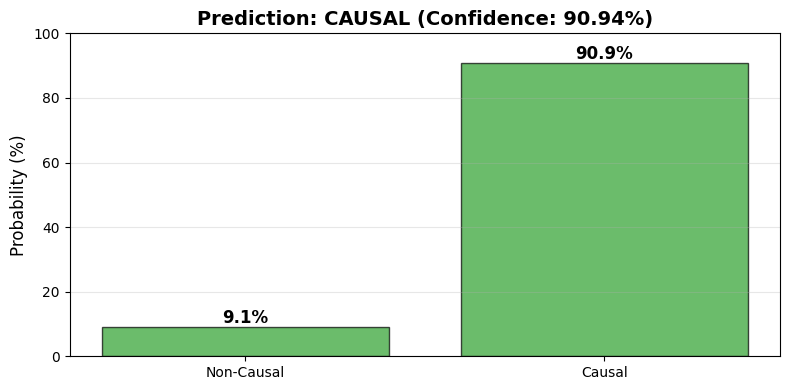

In [26]:
import matplotlib.pyplot as plt

def visualize_prediction(result):
    """
    Create bar chart of prediction probabilities
    """
    probs = [
        float(result['probability_non_causal'].strip('%')),
        float(result['probability_causal'].strip('%'))
    ]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ['#ff7f0e' if result['prediction'] == 'NON-CAUSAL' else '#2ca02c',
              '#2ca02c' if result['prediction'] == 'CAUSAL' else '#ff7f0e']
    
    bars = ax.bar(['Non-Causal', 'Causal'], probs, color=colors, alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for bar, prob in zip(bars, probs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{prob:.1f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.set_ylabel('Probability (%)', fontsize=12)
    ax.set_title(f"Prediction: {result['prediction']} (Confidence: {result['confidence']})", 
                 fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize test case
result = predict_causality(
    "The merger announcement caused both stocks to surge by 15% in after-hours trading.",
    return_t1=0.15,
    return_t5=0.08,
    volatility_5=0.25
)
visualize_prediction(result)

# **INTERPRETATION**:
# - Visual representation of model confidence
# - Green bar = predicted class, Orange = other class
# - Helps identify borderline cases (near 50-50 split)
# - Useful for: debugging, presentations, threshold tuning